In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv(r"E:\Netflix movie dataset\netflix_movie_data.csv")

In [4]:
df.head(10)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,07-01-2022,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,12-01-2022,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,10-02-2022,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,17-02-2022,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,03-11-2021,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [14]:
df.shape

(9837, 9)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [19]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

#### Duplicate records were checked using df.duplicate().sum() and no duplicate rows were found in dataset


In [25]:
df['Release_Date'] = pd.to_datetime(
    df['Release_Date'], 
    format='mixed', 
    dayfirst=True, 
    errors='coerce'
)

In [27]:
df['year']=df['Release_Date'].dt.year

In [28]:
print(df['Release_Date'].head())

0   2021-12-15
1   2022-03-01
2   2022-02-25
3   2021-11-24
4   2021-12-22
Name: Release_Date, dtype: datetime64[us]


## EDA
#### Top 10 Most Popular Movies

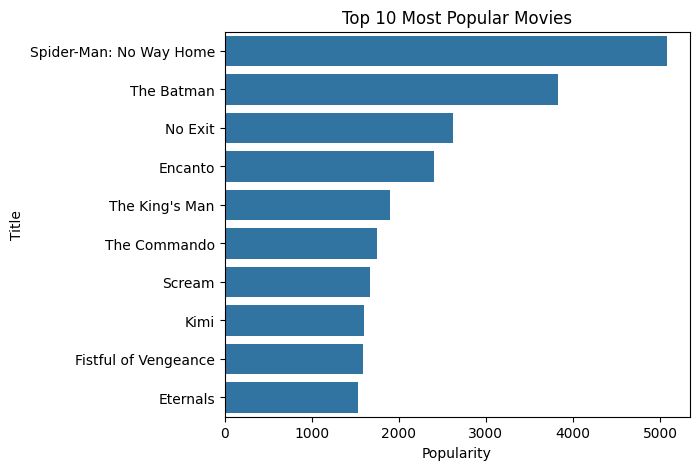

In [5]:
top_movies=df.nlargest(10,'Popularity')

plt.figure(figsize=(6,5))
sns.barplot(x='Popularity',y='Title',data=top_movies)
plt.title('Top 10 Most Popular Movies')
plt.show()

####### The analysis shows that Spider-Man:No way Home is the most popular movie, followed by The Batman . The results suggest that blockbuster and family-oriented movies received the highest audience attention.

#### Top 10 Highest Reated Movies?

In [34]:
df['Vote_Average'].dtype

<StringDtype(storage='python', na_value=nan)>

In [35]:
df['Vote_Average']=pd.to_numeric(df['Vote_Average'],errors='coerce')

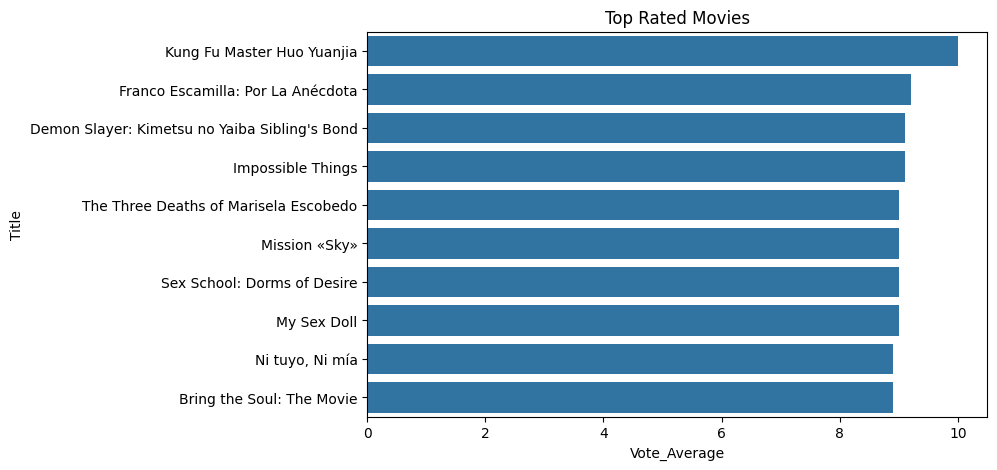

In [36]:
top_movies=df.nlargest(10,'Vote_Average')

plt.figure(figsize=(8,5))
sns.barplot(x='Vote_Average',y='Title',data=top_movies)
plt.title('Top Rated Movies')
plt.show()

###### The analysis reveals that kung Fu Master received the highest average rating among all movies in the dataset, followed by franco and Demon. These movies were highly appreciated by viewers, indicating strong audience satisfaction and positive reviews.

#### Genre-wise Movie count?

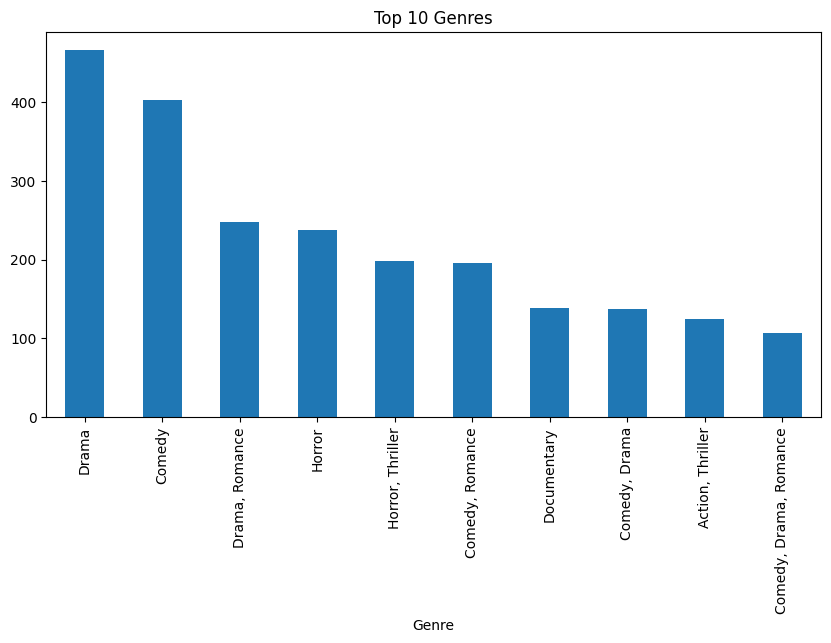

In [38]:
plt.figure(figsize=(10,5))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Genres')
plt.show()

#### Language Distribution

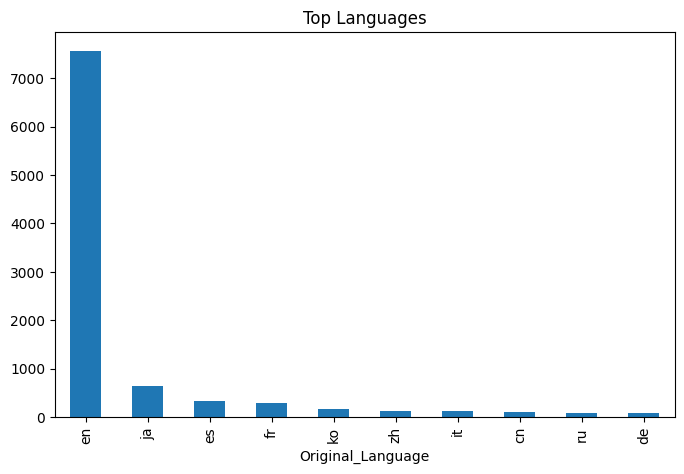

In [39]:
plt.figure(figsize=(8,5))

df['Original_Language'].value_counts().head(10).plot(kind='bar')

plt.title('Top Languages')
plt.show()

#### Popularity Distribution

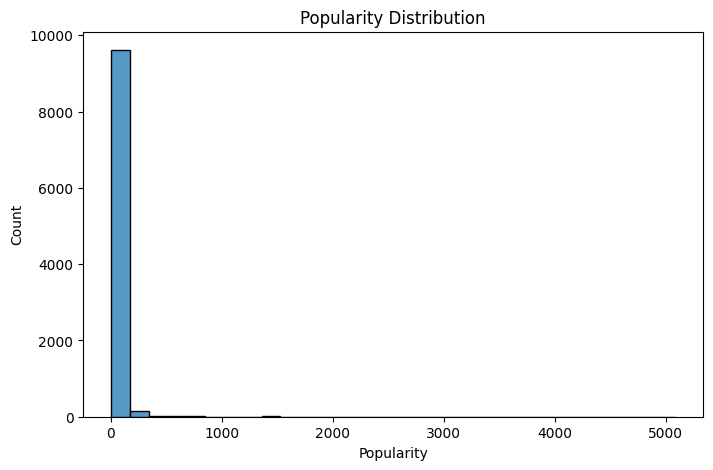

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['Popularity'],bins=30)
plt.title('Popularity Distribution')
plt.show()

###Vote Average Distribution?

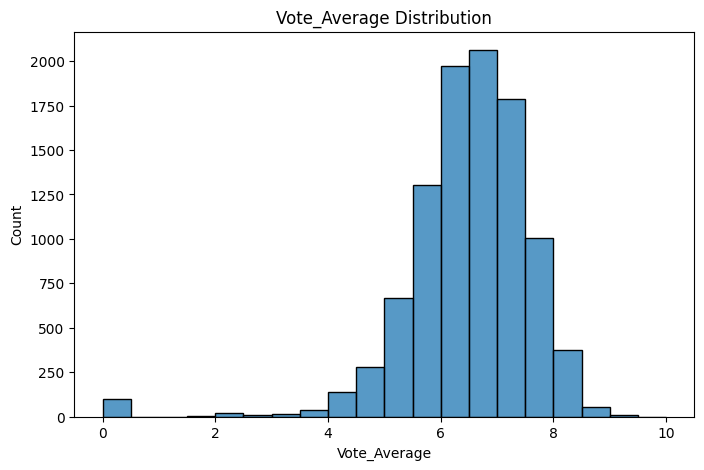

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(df['Vote_Average'],bins=20)
plt.title('Vote_Average Distribution')
plt.show()

####Popularity vs Rating ?

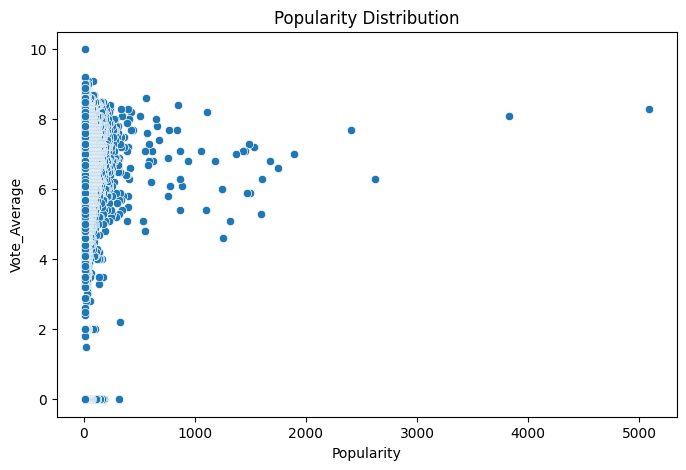

In [44]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Popularity',
                y='Vote_Average', data=df)
                
plt.title('Popularity Distribution')
plt.show()

#### Movies Released Per Year ?

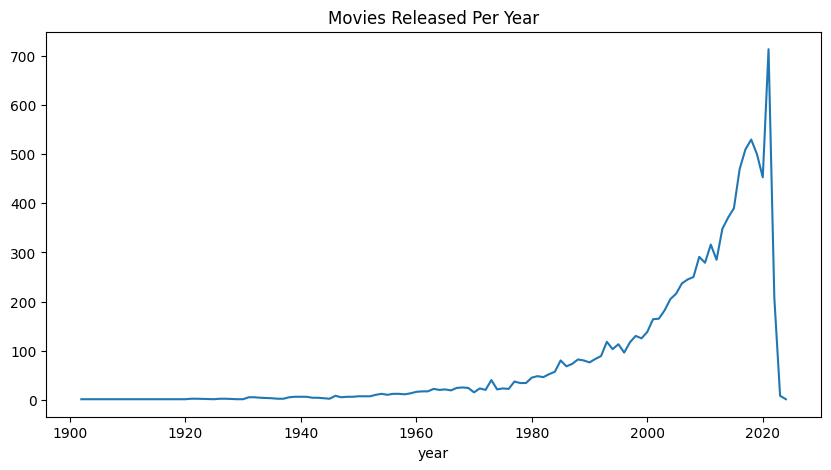

In [46]:
movies_year = df['year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
movies_year.plot()
plt.title('Movies Released Per Year')
plt.show()

##### Correlation Analysis


In [49]:
print(df[['Popularity', 'Vote_Count','Vote_Average']].dtypes)

Popularity      float64
Vote_Count          str
Vote_Average    float64
dtype: object


In [55]:
df['vote_count']=pd.to_numeric(df['Vote_Count'],errors='coerce')

In [56]:
print(df[['Popularity', 'Vote_Count','Vote_Average']].dtypes)

Popularity      float64
Vote_Count          str
Vote_Average    float64
dtype: object


In [59]:
df['Vote_Count'].unique()[:20]

<StringArray>
['8940', '1151',  '122', '5076', '1793',   '33',  '821',  '206',  '114',
 '4726',   '16',  '100',  '107',  '952',  '737',  '288',  '521',   '65',
   '31', '3193']
Length: 20, dtype: str

In [61]:
df['Vote_Count']=pd.to_numeric(df['Vote_Count'].astype(str).str.strip(),
                               errors='coerce')
print(df['Vote_Count'].dtype)

float64


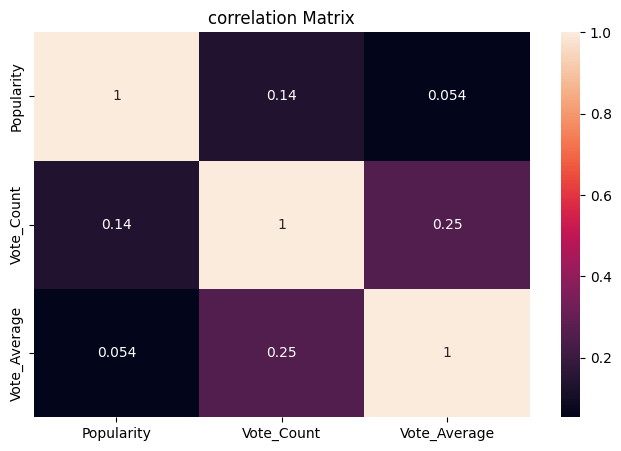

In [62]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Popularity','Vote_Count','Vote_Average']].corr(),annot=True)
plt.title('correlation Matrix')
plt.show()

##### counclusion


The analysis of the Netflix movie dataset highlights clear patterns in popularity, ratings, genres, and release timelines. High-profile titles such as Spider-Man: No Way Home and The Batman dominate both popularity and average ratings, reflecting strong audience engagement with blockbuster action and superhero films. Family-oriented animations like Encanto also perform well, showing the broad appeal of diverse genres. Meanwhile, thrillers and crime dramas exhibit moderate ratings, suggesting niche but consistent interest.